In [1]:
import torch

import triton
import triton.language as tl
from triton.runtime import driver

DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [2]:
@triton.jit
def add_kernel(x_ptr,  # *Pointer* to first input vector.
               y_ptr,  # *Pointer* to second input vector.
               output_ptr,  # *Pointer* to output vector.
               n_elements,  # Size of the vector.
               BLOCK_SIZE: tl.constexpr,  # Number of elements each program should process.
               # NOTE: `constexpr` so it can be used as a shape value.
               ):

    pid = tl.program_id(axis=0) # handles the vector block wise 
    # pid=0 → handles elements [0:256]
    # pid=1 → handles elements [256:512]
    # pid=2 → handles elements [512:768]
    # pid=3 → handles elements [768:1024]

    block_start = pid * BLOCK_SIZE # e.g. pid=2, BLOCK_SIZE=4 → 8
    offsets = block_start + tl.arange(0, BLOCK_SIZE) # 8 + [0,1,2,3] → [8,9,10,11]

    # Create a mask to guard memory operations against out-of-bounds accesses.
    mask = offsets < n_elements

    # Load x and y from DRAM, masking out any extra elements in case the input is not a
    # multiple of the block size.
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)

    output = x + y
    # Write x + y back to DRAM.
    tl.store(output_ptr + offsets, output, mask=mask)

In [3]:
def add(x: torch.Tensor, y: torch.Tensor):
    # We need to preallocate the output.
    output = torch.empty_like(x)
    assert x.device == DEVICE and y.device == DEVICE and output.device == DEVICE
    n_elements = output.numel()
    # The SPMD launch grid denotes the number of kernel instances that run in parallel.
    # It is analogous to CUDA launch grids. It can be either Tuple[int], or Callable(metaparameters) -> Tuple[int].
    # In this case, we use a 1D grid where the size is the number of blocks:
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']), )
    # NOTE:
    #  - Each torch.tensor object is implicitly converted into a pointer to its first element.
    #  - `triton.jit`'ed functions can be indexed with a launch grid to obtain a callable GPU kernel.
    #  - Don't forget to pass meta-parameters as keywords arguments.
    add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=1024)
    # We return a handle to z but, since `torch.cuda.synchronize()` hasn't been called, the kernel is still
    # running asynchronously at this point.
    return output

In [4]:
torch.manual_seed(0)
size = 98432
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

tensor([1.3713, 1.3076, 0.4940,  ..., 0.4024, 1.7918, 1.0686], device='cuda:0')
tensor([1.3713, 1.3076, 0.4940,  ..., 0.4024, 1.7918, 1.0686], device='cuda:0')
The maximum difference between torch and triton is 0.0


In [5]:
# mostly for checking which type of GPU: AMD or NVIDIA

def is_hip():
    return triton.runtime.driver.active.get_current_target().backend == "hip"


def is_cdna():
    return is_hip() and triton.runtime.driver.active.get_current_target().arch in ('gfx940', 'gfx941', 'gfx942',
                                                                                   'gfx90a', 'gfx908')

In [6]:
def naive_softmax(x):
    """Compute row-wise softmax of X using native pytorch

    We subtract the maximum element in order to avoid overflows. Softmax is invariant to
    this shift.
    """
    # read  MN elements ; write M  elements
    x_max = x.max(dim=1)[0]
    # read MN + M elements ; write MN elements
    z = x - x_max[:, None]
    # read  MN elements ; write MN elements
    numerator = torch.exp(z)
    # read  MN elements ; write M  elements
    denominator = numerator.sum(dim=1)
    # read MN + M elements ; write MN elements
    ret = numerator / denominator[:, None]
    # in total: read 5MN + 2M elements ; wrote 3MN + 2M elements
    return ret

In [7]:
@triton.jit
def softmax_kernel(output_ptr, input_ptr, input_row_stride, output_row_stride, n_rows, n_cols, BLOCK_SIZE: tl.constexpr,
                   num_stages: tl.constexpr):
    # starting row of the program
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0)
    for row_idx in tl.range(row_start, n_rows, row_step, num_stages=num_stages):
        # The stride represents how much we need to increase the pointer to advance 1 row
        row_start_ptr = input_ptr + row_idx * input_row_stride
        # The block size is the next power of two greater than n_cols, so we can fit each
        # row in a single block
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        # Load the row into SRAM, using a mask since BLOCK_SIZE may be > than n_cols
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask=mask, other=-float('inf'))
        # Subtract maximum for numerical stability
        row_minus_max = row - tl.max(row, axis=0)
        # Note that exponentiation in Triton is fast but approximate (i.e., think __expf in CUDA)
        numerator = tl.exp(row_minus_max)
        denominator = tl.sum(numerator, axis=0)
        softmax_output = numerator / denominator
        # Write back output to DRAM
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask=mask)

In [8]:
properties = driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM = properties["multiprocessor_count"]
NUM_REGS = properties["max_num_regs"]
SIZE_SMEM = properties["max_shared_mem"]
WARP_SIZE = properties["warpSize"]
target = triton.runtime.driver.active.get_current_target()
kernels = {}


def softmax(x):
    n_rows, n_cols = x.shape

    # The block size of each loop iteration is the smallest power of two greater than the number of columns in `x`
    BLOCK_SIZE = triton.next_power_of_2(n_cols)

    # Another trick we can use is to ask the compiler to use more threads per row by
    # increasing the number of warps (`num_warps`) over which each row is distributed.
    # You will see in the next tutorial how to auto-tune this value in a more natural
    # way so you don't have to come up with manual heuristics yourself.
    num_warps = 8

    # Number of software pipelining stages.
    num_stages = 4 if SIZE_SMEM > 200000 else 2

    # Allocate output
    y = torch.empty_like(x)

    # pre-compile kernel to get register usage and compute thread occupancy.
    kernel = softmax_kernel.warmup(y, x, x.stride(0), y.stride(0), n_rows, n_cols, BLOCK_SIZE=BLOCK_SIZE,
                                   num_stages=num_stages, num_warps=num_warps, grid=(1, ))
    kernel._init_handles()
    n_regs = kernel.n_regs
    size_smem = kernel.metadata.shared
    if is_hip():
        # NUM_REGS represents the number of regular purpose registers. On CDNA architectures this is half of all registers available.
        # However, this is not always the case. In most cases all registers can be used as regular purpose registers.
        # ISA SECTION (3.6.4 for CDNA3)
        # VGPRs are allocated out of two pools: regular VGPRs and accumulation VGPRs. Accumulation VGPRs are used
        # with matrix VALU instructions, and can also be loaded directly from memory. A wave may have up to 512 total
        # VGPRs, 256 of each type. When a wave has fewer than 512 total VGPRs, the number of each type is flexible - it is
        # not required to be equal numbers of both types.
        NUM_GPRS = NUM_REGS
        if is_cdna():
            NUM_GPRS = NUM_REGS * 2

        # MAX_NUM_THREADS represents maximum number of resident threads per multi-processor.
        # When we divide this number with WARP_SIZE we get maximum number of waves that can
        # execute on a CU (multi-processor)  in parallel.
        MAX_NUM_THREADS = properties["max_threads_per_sm"]
        max_num_waves = MAX_NUM_THREADS // WARP_SIZE
        occupancy = min(NUM_GPRS // WARP_SIZE // n_regs, max_num_waves) // num_warps
    else:
        occupancy = NUM_REGS // (n_regs * WARP_SIZE * num_warps)
    occupancy = min(occupancy, SIZE_SMEM // size_smem)
    num_programs = NUM_SM * occupancy

    num_programs = min(num_programs, n_rows)

    # Create a number of persistent programs.
    kernel[(num_programs, 1, 1)](y, x, x.stride(0), y.stride(0), n_rows, n_cols, BLOCK_SIZE, num_stages)
    return y

In [9]:
torch.manual_seed(0)
x = torch.randn(1823, 781, device=DEVICE)
y_triton = softmax(x)
y_torch = torch.softmax(x, axis=1)
assert torch.allclose(y_triton, y_torch), (y_triton, y_torch)

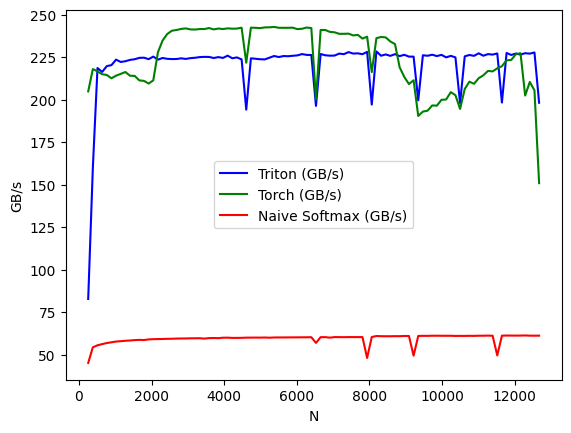

In [10]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['triton', 'torch', 'naive_softmax'],  # possible values for `line_arg``
        line_names=["Triton", "Torch", "Naive Softmax"],  # label name for the lines
        styles=[('blue', '-'), ('green', '-'), ('red', '-')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)
    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda: softmax(x))
    if provider == 'naive_softmax':
        ms = triton.testing.do_bench(lambda: naive_softmax(x))
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)


benchmark.run(show_plots=True)

In [16]:
import triton
import triton.language as tl

@triton.jit
def flash_attention_kernel(
    Q_ptr, K_ptr, V_ptr, O_ptr,
    T,  d_k: tl.constexpr,
    TILE_SIZE: tl.constexpr,):
    

    # 1. get program id — which Q block are we handling?
    pid = tl.program_id(axis = 0)
    
    # 2. compute offsets for Q block
    tile_start = pid * TILE_SIZE 
    offset = tile_start + tl.arange(0,TILE_SIZE)

    row_offsets = offset[:, None]      # shape (TILE_SIZE, 1)
    col_offsets = tl.arange(0, d_k)[None, :]  # shape (1, d_k)

    Q_offsets = row_offsets * d_k + col_offsets  # shape (TILE_SIZE, d_k)

    mask = row_offsets < T

    Q = tl.load(Q_ptr + Q_offsets, mask = mask)
    
    # 3. initialize m, run_denom, run_numer

    m = tl.full((TILE_SIZE,), value=float('-inf'), dtype=tl.float32)
    run_denom = tl.full((TILE_SIZE,), value=0.0, dtype=tl.float32)
    run_numer = tl.full((TILE_SIZE, d_k), value=0.0, dtype=tl.float32)
    
    # 4. loop over K, V blocks
    for j in range(0,T,TILE_SIZE):

        offset2 = j + tl.arange(0,TILE_SIZE)
        row_offsets2 = offset2[:, None]      
        col_offsets2 = tl.arange(0, d_k)[None, :]

        k_offsets = row_offsets2 * d_k + col_offsets2
        v_offsets = row_offsets2 * d_k + col_offsets2

        mask2 = row_offsets2 < T

        K = tl.load(K_ptr + k_offsets, mask = mask2)
        V = tl.load(V_ptr + v_offsets, mask = mask2)

        score = tl.dot(Q, tl.trans(K)) / (d_k ** 0.5)

        m_new = tl.maximum(m, tl.max(score, axis= 1))
        corr_factor = tl.exp(m - m_new)
        run_denom = run_denom * corr_factor + tl.sum(tl.exp(score - m_new[:, None]), axis=1)
        run_numer = run_numer * corr_factor[:, None] + tl.dot(tl.exp(score - m_new[:, None]), V)
        m = m_new
    
    # 5. compute output and store to HBM
    out_block = run_numer / run_denom[:, None]
    tl.store(O_ptr + Q_offsets, out_block, mask=mask)

In [17]:
def flash_attention_triton(Q, K, V, tile_size=16):
    B, H, T, d_k = Q.shape
    O = torch.zeros_like(Q)
    
    grid = (T // tile_size,)
    
    for b in range(B):
        for h in range(H):
            flash_attention_kernel[grid](
                Q[b, h], K[b, h], V[b, h], O[b, h],
                T, d_k,
                TILE_SIZE=tile_size
            )
    return O

In [18]:
def naive_attention(Q,K,V):

    d_k = Q.shape[-1]

    score = Q @ K.transpose(-2,-1) / d_k**0.5
    attn = torch.softmax(score, dim=-1)
    out = attn @ V
    return out


In [19]:
Q = torch.randn(1, 1, 64, 32).cuda()
K = torch.randn(1, 1, 64, 32).cuda()
V = torch.randn(1, 1, 64, 32).cuda()

naive_out = naive_attention(Q, K, V)
triton_out = flash_attention_triton(Q, K, V, tile_size=16)

print(torch.allclose(naive_out, triton_out, atol=1e-3))
print(torch.max(torch.abs(naive_out - triton_out)))

True
tensor(4.1723e-07, device='cuda:0')


In [20]:
import time

def benchmark(fn, *args, n_runs=10):
    # warmup
    for _ in range(3):
        fn(*args)
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(n_runs):
        fn(*args)
    torch.cuda.synchronize()
    return (time.time() - start) / n_runs * 1000

for T in [128, 256, 512, 1024, 2048]:
    Q = torch.randn(1, 1, T, 64).cuda()
    K = torch.randn(1, 1, T, 64).cuda()
    V = torch.randn(1, 1, T, 64).cuda()
    
    naive_t = benchmark(naive_attention, Q, K, V)
    triton_t = benchmark(flash_attention_triton, Q, K, V)
    
    print(f"T={T} | Naive: {naive_t:.2f}ms | Triton: {triton_t:.2f}ms | Speedup: {naive_t/triton_t:.2f}x")

T=128 | Naive: 0.10ms | Triton: 0.07ms | Speedup: 1.40x
T=256 | Naive: 0.10ms | Triton: 0.11ms | Speedup: 0.89x
T=512 | Naive: 0.10ms | Triton: 0.35ms | Speedup: 0.28x
T=1024 | Naive: 0.25ms | Triton: 1.26ms | Speedup: 0.20x
T=2048 | Naive: 0.84ms | Triton: 4.41ms | Speedup: 0.19x


In [21]:
for T in [4096, 8192]:
    Q = torch.randn(1, 1, T, 64).cuda()
    K = torch.randn(1, 1, T, 64).cuda()
    V = torch.randn(1, 1, T, 64).cuda()
    
    naive_t = benchmark(naive_attention, Q, K, V)
    triton_t = benchmark(flash_attention_triton, Q, K, V)
    
    print(f"T={T} | Naive: {naive_t:.2f}ms | Triton: {triton_t:.2f}ms | Speedup: {naive_t/triton_t:.2f}x")

T=4096 | Naive: 3.41ms | Triton: 12.32ms | Speedup: 0.28x
T=8192 | Naive: 10.36ms | Triton: 24.40ms | Speedup: 0.42x


In [22]:
for T in [1024, 2048, 4096]:
    Q = torch.randn(1, 1, T, 64).cuda()
    K = torch.randn(1, 1, T, 64).cuda()
    V = torch.randn(1, 1, T, 64).cuda()
    
    torch.cuda.reset_peak_memory_stats()
    naive_attention(Q, K, V)
    naive_mem = torch.cuda.max_memory_allocated() / 1024**2
    
    torch.cuda.reset_peak_memory_stats()
    flash_attention_triton(Q, K, V)
    triton_mem = torch.cuda.max_memory_allocated() / 1024**2
    
    print(f"T={T} | Naive: {naive_mem:.1f}MB | Triton: {triton_mem:.1f}MB")

T=1024 | Naive: 34.7MB | Triton: 26.7MB
T=2048 | Naive: 59.7MB | Triton: 27.7MB
T=4096 | Naive: 157.7MB | Triton: 29.7MB
